# ETTh1 / ETTh2 эксперименты: LSTM + Optuna, Informer + Optuna, LLM-агент

В этом ноутбуке запускаются три подхода к задаче прогноза временных рядов на датасетах **ETTh1** и **ETTh2**:

1. **LSTM + Optuna**  
   Поиск гиперпараметров LSTM с помощью Optuna и обучение лучшей модели.  
   Сохраняются:
   - метрики качества (MSE);
   - ресурсные метрики (время, память, энергия GPU);
   - предсказания на валидации.

2. **Informer + Optuna**  
   Внешний запуск оригинальной реализации Informer через обёртку и поиск гиперпараметров с Optuna.  
   Сохраняются:
   - метрики качества;
   - ресурсные метрики;
   - предсказания на валидации.

3. **LLM-агент**  
   Агент на основе LLM:
   - генерирует PyTorch-пайплайны для ETT-формата (кандидаты);
   - обучает каждый кандидат на обучающей выборке;
   - оценивает на валидации по MSE;
   - использует кроссовер лучших кандидатов для генерации новых.

В конце ноутбука строятся сравнительные таблицы и графики:

- сравнение MSE между всеми подходами;
- сравнение ресурсных метрик (время, память, энергия);
- динамика поиска LLM-агента по кандидатам.

Все пути и гиперпараметры задаются через переменные в первой кодовой ячейке и `.env` в корне проекта (`/edlm_search/.env`).


In [1]:
from __future__ import annotations

import logging
import os
import sys
from dataclasses import dataclass
from pathlib import Path
from typing import Dict
from typing import List
from typing import Tuple

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from dotenv import load_dotenv


def find_repo_root() -> Path:
    """Locate project root directory that contains 'src/edlm_search'."""
    current = Path.cwd().resolve()
    for candidate in (current, current.parent):
        if (candidate / 'src' / 'edlm_search').is_dir():
            return candidate
    raise RuntimeError('Cannot locate project root with "src/edlm_search" directory.')


REPO_ROOT: Path = find_repo_root()
SRC_DIR: Path = REPO_ROOT / 'src'

if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

ENV_PATH: Path = REPO_ROOT / '.env'
if ENV_PATH.is_file():
    load_dotenv(dotenv_path=ENV_PATH)

from edlm_search.experiments import (
    ExperimentResult,
    run_informer_optuna_etth_experiment,
    run_lstm_optuna_etth_experiment,
)
from edlm_search.agent.candidate import Candidate
from edlm_search.agent.ett_evaluator import ETTEvaluator
from edlm_search.agent.llm_clients import DeepSeekClient, LMStudioClient
from edlm_search.agent.llm_pipeline import LLMPipeline
from edlm_search.agent.problem import Problem
from edlm_search.agent.runner import UnsafeRunner
from edlm_search.experiments.datasets import load_ett_csv_dataset


@dataclass
class DatasetConfig:
    """Dataset configuration for ETTh experiments."""

    name: str
    csv_path: Path
    max_rows: int
    train_ratio: float


@dataclass
class LSTMOptunaConfig:
    """Configuration for LSTM + Optuna baseline."""

    seq_len: int
    pred_len: int
    num_epochs: int
    n_trials: int
    target_column: str
    model_name: str
    artifacts_dir: Path
    device_type: str


@dataclass
class InformerOptunaConfig:
    """Configuration for Informer + Optuna baseline."""

    num_epochs: int
    timeout_seconds: int
    n_trials: int
    metrics_root_dir: Path


@dataclass
class LLMSearchConfig:
    """Configuration for the LLM-based architecture search."""

    metric_name: str
    num_epochs_per_candidate: int
    num_initial_candidates: int
    num_crossover_candidates: int


@dataclass
class LLMProviderConfig:
    """Configuration of the LLM provider used by the agent."""

    provider: str
    base_url: str
    model_name: str
    api_key_env_var: str


ETT_DATA_DIR: Path = SRC_DIR / 'ETDataset' / 'ETT-small'
ETTH1_PATH: Path = ETT_DATA_DIR / 'ETTh1.csv'
ETTH2_PATH: Path = ETT_DATA_DIR / 'ETTh2.csv'

MAX_ROWS: int = int(os.getenv('MAX_ROWS', '10000'))
TRAIN_RATIO: float = float(os.getenv('TRAIN_RATIO', '0.8'))

TARGET_COLUMN: str = os.getenv('TARGET_COLUMN', 'OT')

LSTM_SEQ_LEN: int = int(os.getenv('SEQ_LEN', '96'))
LSTM_PRED_LEN: int = int(os.getenv('PRED_LEN', '24'))
LSTM_NUM_EPOCHS: int = int(os.getenv('NUM_EPOCHS', '5'))
LSTM_N_TRIALS: int = int(os.getenv('N_TRIALS', '20'))
LSTM_MODEL_NAME: str = os.getenv('LSTM_MODEL_NAME', 'lstm-optuna')
ARTIFACTS_DIR: Path = (REPO_ROOT / os.getenv('ARTIFACTS_DIR', 'artifacts')).resolve()
DEVICE_TYPE: str = os.getenv('DEVICE_TYPE', 'auto')

INFORMER_NUM_EPOCHS: int = int(os.getenv('INFORMER_NUM_EPOCHS', '10'))
INFORMER_TIMEOUT_SECONDS: int = int(os.getenv('INFORMER_TIMEOUT_SECONDS', '3600'))
INFORMER_N_TRIALS: int = int(os.getenv('INFORMER_N_TRIALS', '10'))
INFORMER_METRICS_ROOT: Path = (
        REPO_ROOT / os.getenv('INFORMER_METRICS_ROOT', 'artifacts/informer_optuna')
).resolve()

LLM_METRIC_NAME: str = os.getenv('LLM_METRIC_NAME', 'mse')
LLM_NUM_EPOCHS_PER_CANDIDATE: int = int(os.getenv('LLM_NUM_EPOCHS', '5'))
LLM_NUM_INITIAL_CANDIDATES: int = int(os.getenv('LLM_NUM_INITIAL_CANDIDATES', '2'))
LLM_NUM_CROSSOVER_CANDIDATES: int = int(os.getenv('LLM_NUM_CROSSOVER_CANDIDATES', '3'))

LLM_PROVIDER_NAME: str = os.getenv('LLM_PROVIDER', 'lmstudio')
LLM_BASE_URL: str = os.getenv('LLM_BASE_URL', 'http://localhost:1234/v1')
LLM_MODEL_NAME: str = os.getenv('LLM_MODEL_NAME', 'your-lmstudio-model-name')
LLM_API_KEY_ENV_VAR: str = 'DEEPSEEK_API_KEY'

STATEMENT_PATH: Path = SRC_DIR / 'statement.md'

dataset_configs: List[DatasetConfig] = [
    DatasetConfig(
            name='ETTh1',
            csv_path=ETTH1_PATH,
            max_rows=MAX_ROWS,
            train_ratio=TRAIN_RATIO,
    ),
    DatasetConfig(
            name='ETTh2',
            csv_path=ETTH2_PATH,
            max_rows=MAX_ROWS,
            train_ratio=TRAIN_RATIO,
    ),
]

lstm_optuna_config = LSTMOptunaConfig(
        seq_len=LSTM_SEQ_LEN,
        pred_len=LSTM_PRED_LEN,
        num_epochs=LSTM_NUM_EPOCHS,
        n_trials=LSTM_N_TRIALS,
        target_column=TARGET_COLUMN,
        model_name=LSTM_MODEL_NAME,
        artifacts_dir=ARTIFACTS_DIR,
        device_type=DEVICE_TYPE,
)

informer_optuna_config = InformerOptunaConfig(
        num_epochs=INFORMER_NUM_EPOCHS,
        timeout_seconds=INFORMER_TIMEOUT_SECONDS,
        n_trials=INFORMER_N_TRIALS,
        metrics_root_dir=INFORMER_METRICS_ROOT,
)

llm_search_config = LLMSearchConfig(
        metric_name=LLM_METRIC_NAME,
        num_epochs_per_candidate=LLM_NUM_EPOCHS_PER_CANDIDATE,
        num_initial_candidates=LLM_NUM_INITIAL_CANDIDATES,
        num_crossover_candidates=LLM_NUM_CROSSOVER_CANDIDATES,
)

llm_provider_config = LLMProviderConfig(
        provider=LLM_PROVIDER_NAME,
        base_url=LLM_BASE_URL,
        model_name=LLM_MODEL_NAME,
        api_key_env_var=LLM_API_KEY_ENV_VAR,
)

ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)
INFORMER_METRICS_ROOT.mkdir(parents=True, exist_ok=True)

logging.basicConfig(
        level=logging.INFO,
        format='%(asctime)s - %(levelname)s - %(name)s - %(message)s',
)
logger = logging.getLogger('etth_experiments')

logger.info(f'Repository root: {REPO_ROOT}')
logger.info(f'ETT data directory: {ETT_DATA_DIR}')
logger.info(f'Artifacts directory: {ARTIFACTS_DIR}')
logger.info(f'Informer metrics root: {INFORMER_METRICS_ROOT}')
logger.info(f'LLM provider: {llm_provider_config.provider}')


/Users/roman/Projects/PycharmProjects/ITMO/edlm_search/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2025-11-19 19:50:06,756 - INFO - etth_experiments - Repository root: /Users/roman/Projects/PycharmProjects/ITMO/edlm_search
2025-11-19 19:50:06,756 - INFO - etth_experiments - ETT data directory: /Users/roman/Projects/PycharmProjects/ITMO/edlm_search/src/ETDataset/ETT-small
2025-11-19 19:50:06,756 - INFO - etth_experiments - Artifacts directory: /Users/roman/Projects/PycharmProjects/ITMO/edlm_search/artifacts
2025-11-19 19:50:06,757 - INFO - etth_experiments - Informer metrics root: /Users/roman/Projects/PycharmProjects/ITMO/edlm_search/artifacts/informer_optuna
2025-11-19 19:50:06,757 - INFO - etth_experiments - LLM provider: lmstudio


## 1. Загрузка и разбиение датасетов ETTh1 и ETTh2

На этом этапе выполняется только **предобработка данных**:

1. Чтение CSV-файлов `ETTh1.csv` и `ETTh2.csv`.
2. Ограничение числа строк `MAX_ROWS` (если задано).
3. Временное разбиение на обучающую и валидационную части по доле `TRAIN_RATIO`.

Модели здесь ещё не обучаются.


In [2]:
def load_single_dataset(config: DatasetConfig) -> Tuple[pd.DataFrame, pd.DataFrame]:
    """Load ETTh dataset from CSV and split into train and validation parts."""
    if not config.csv_path.is_file():
        raise FileNotFoundError(f'Dataset {config.name} not found at {config.csv_path}')
    train_df, valid_df = load_ett_csv_dataset(
            csv_path=str(config.csv_path),
            max_rows=config.max_rows,
            train_ratio=config.train_ratio,
    )
    logger.info(
            f'Dataset {config.name} loaded: train_rows={len(train_df)}, '
            f'valid_rows={len(valid_df)}, max_rows={config.max_rows}, '
            f'train_ratio={config.train_ratio}'
    )
    return train_df, valid_df


def load_all_datasets(configs: List[DatasetConfig]) -> Tuple[Dict[str, pd.DataFrame], Dict[str, pd.DataFrame]]:
    """Load and split all configured datasets."""
    train_dfs: Dict[str, pd.DataFrame] = {}
    valid_dfs: Dict[str, pd.DataFrame] = {}
    for cfg in configs:
        train_df, valid_df = load_single_dataset(cfg)
        train_dfs[cfg.name] = train_df
        valid_dfs[cfg.name] = valid_df
    return train_dfs, valid_dfs


train_dfs, valid_dfs = load_all_datasets(dataset_configs)
train_dfs.keys(), valid_dfs.keys()


2025-11-19 19:50:20,729 - INFO - etth_experiments - Dataset ETTh1 loaded: train_rows=8000, valid_rows=2000, max_rows=10000, train_ratio=0.8
2025-11-19 19:50:20,749 - INFO - etth_experiments - Dataset ETTh2 loaded: train_rows=8000, valid_rows=2000, max_rows=10000, train_ratio=0.8


(dict_keys(['ETTh1', 'ETTh2']), dict_keys(['ETTh1', 'ETTh2']))

## 2. LSTM + Optuna: поиск гиперпараметров и обучение лучшей модели

На этом этапе:

1. Для каждого датасета (ETTh1, ETTh2) запускается **Optuna-поиск гиперпараметров** LSTM:
   - длина скрытого состояния;
   - число слоёв;
   - скорость обучения;
   - размер батча.

2. Для лучшей конфигурации выполняется **обучение модели LSTM** с заданным числом эпох `NUM_EPOCHS`.

3. После обучения:
   - считается MSE на валидации;
   - собираются ресурсные метрики (wall-time, CPU, память, энергия GPU);
   - сохраняются предсказания на валидации в `ARTIFACTS_DIR`.

Эта ячейка отвечает за **обучение и валидацию LSTM-модели**.


In [3]:
def run_lstm_optuna_for_all_datasets(
        configs: List[DatasetConfig],
        lstm_config: LSTMOptunaConfig,
) -> Dict[str, ExperimentResult]:
    """Run LSTM + Optuna baseline for all datasets and return results."""
    results: Dict[str, ExperimentResult] = {}
    for cfg in configs:
        if not cfg.csv_path.is_file():
            logger.info(
                    f'[LSTM+Optuna] Dataset {cfg.name} skipped: missing CSV at {cfg.csv_path}'
            )
            continue
        logger.info(
                f'[LSTM+Optuna] Starting search for dataset={cfg.name}, '
                f'seq_len={lstm_config.seq_len}, pred_len={lstm_config.pred_len}, '
                f'epochs={lstm_config.num_epochs}, n_trials={lstm_config.n_trials}, '
                f'device_type={lstm_config.device_type}'
        )
        result = run_lstm_optuna_etth_experiment(
                dataset_name=cfg.name,
                csv_path=str(cfg.csv_path),
                max_rows=cfg.max_rows,
                train_ratio=cfg.train_ratio,
                seq_len=lstm_config.seq_len,
                pred_len=lstm_config.pred_len,
                num_epochs=lstm_config.num_epochs,
                n_trials=lstm_config.n_trials,
                target_column=lstm_config.target_column,
                model_name=lstm_config.model_name,
                artifacts_dir=str(lstm_config.artifacts_dir),
                device_type=lstm_config.device_type,
        )
        results[cfg.name] = result
        mse_value = float(result.metrics.get('mse', float('nan')))
        logger.info(
                f'[LSTM+Optuna] Finished for dataset={cfg.name}, mse={mse_value}'
        )
    return results


lstm_optuna_results = run_lstm_optuna_for_all_datasets(
        configs=dataset_configs,
        lstm_config=lstm_optuna_config,
)
lstm_optuna_results


2025-11-19 19:50:53,836 - INFO - etth_experiments - [LSTM+Optuna] Starting search for dataset=ETTh1, seq_len=96, pred_len=24, epochs=5, n_trials=20, device_type=auto
2025-11-19 19:50:53,837 - INFO - edlm_search.experiments.experiment_api - Запуск LSTM+Optuna для датасета "ETTh1" с 20 испытаниями.
2025-11-19 19:50:53,868 - INFO - edlm_search.experiments.experiment_api - Для LSTM+Optuna-эксперимента будет использовано устройство "mps".
2025-11-19 19:50:53,886 - INFO - edlm_search.baselines.baseline_optuna - Optuna LSTM search will use device "mps".
[I 2025-11-19 19:50:53,887] A new study created in memory with name: etth_lstm_mse
2025-11-19 19:51:15,239 - INFO - edlm_search.baselines.baseline_optuna - LSTM training finished: train_time=20.008s, eval_time=0.560s, mse=17.180779
[I 2025-11-19 19:51:15,240] Trial 0 finished with value: 17.18077850341797 and parameters: {'hidden_size': 86, 'num_layers': 2, 'learning_rate': 0.009797078670401735, 'batch_size': 32}. Best is trial 0 with value: 1

{'ETTh1': ExperimentResult(model_name='lstm-optuna', dataset_name='ETTh1', metrics={'mse': 15.167259216308594, 'train_time_seconds': 12.237930125033017, 'eval_time_seconds': 0.4138724160147831, 'total_energy_joules': 0.0, 'peak_gpu_memory_mb': 0.0, 'max_rss_mb': 723328.0, 'wall_seconds_total': 12.704191750031896, 'cpu_user_seconds_total': 9.292152832, 'cpu_system_seconds_total': 0.4752629759999998, 'rss_mb_delta': 13.578125, 'gpu_total_energy_joules': 0.0}, extra_info={'seq_len': 96.0, 'pred_len': 24.0, 'hidden_size': 172.0, 'num_layers': 2.0, 'learning_rate': 0.005511210669565999, 'batch_size': 64.0, 'num_epochs': 5.0, 'predictions_csv_path': '/Users/roman/Projects/PycharmProjects/ITMO/edlm_search/artifacts/lstm-optuna_ETTh1_valid_predictions.csv', 'diagnostics_json_path': '/Users/roman/Projects/PycharmProjects/ITMO/edlm_search/artifacts/lstm-optuna_ETTh1_diagnostics.json', 'resource_monitoring': {'wall_seconds_total': 12.704191750031896, 'cpu_user_seconds_total': 9.292152832, 'cpu_sy

### 2.1. Визуализация предсказаний LSTM на валидации

На этом этапе **обучение не выполняется**.  

Мы:

1. Читаем сохранённые CSV с предсказаниями LSTM для валидации.  
2. Строим графики `y_true` vs `y_pred` для первых `N` точек.

Это помогает визуально оценить качество прогноза.


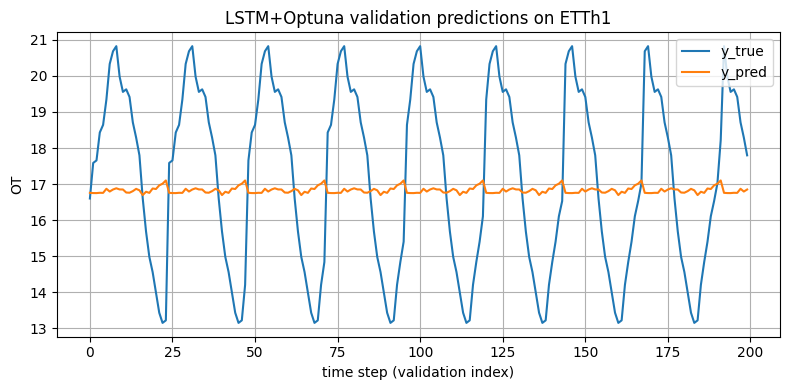

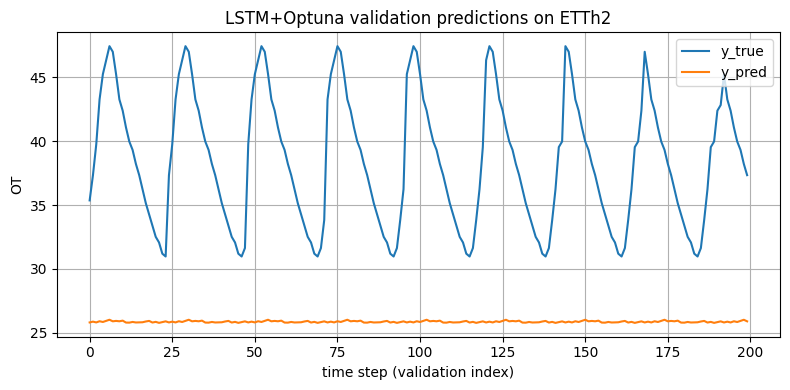

In [4]:
def load_predictions_csv(path: Path) -> pd.DataFrame:
    """Load validation predictions CSV with columns 'y_true' and 'y_pred'."""
    if not path.is_file():
        raise FileNotFoundError(f'Predictions CSV not found at {path}')
    df = pd.read_csv(path)
    if 'y_true' not in df.columns or 'y_pred' not in df.columns:
        raise ValueError(
                f'Predictions CSV at {path} must contain columns "y_true" and "y_pred".'
        )
    return df


def plot_validation_predictions(
        df: pd.DataFrame,
        title: str,
        max_points: int,
) -> None:
    """Plot ground truth and predictions for validation data."""
    subset = df.head(max_points)
    index = np.arange(len(subset))
    plt.figure(figsize=(8, 4))
    plt.plot(index, subset['y_true'], label='y_true')
    plt.plot(index, subset['y_pred'], label='y_pred')
    plt.xlabel('time step (validation index)')
    plt.ylabel(TARGET_COLUMN)
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


for cfg in dataset_configs:
    dataset_name = cfg.name
    predictions_path = ARTIFACTS_DIR / f'{lstm_optuna_config.model_name}_{dataset_name}_valid_predictions.csv'
    if not predictions_path.is_file():
        logger.info(
                f'[{dataset_name}] LSTM predictions CSV not found at {predictions_path}; skipping plot.'
        )
        continue
    df_pred = load_predictions_csv(predictions_path)
    plot_validation_predictions(
            df=df_pred,
            title=f'LSTM+Optuna validation predictions on {dataset_name}',
            max_points=200,
    )


## 3. Informer + Optuna: внешний запуск и подбор гиперпараметров

На этом этапе:

1. Для каждого датасета запускается **Informer + Optuna** через обёртку `Informer2020/informer_experiment_wrapper.py`.
2. Optuna подбирает гиперпараметры Informer (размеры слоёв, число голов, dropout и т.д.).
3. Для лучшей конфигурации внешняя реализация Informer:
   - обучается заданное число эпох `INFORMER_NUM_EPOCHS`;
   - вычисляет метрики на валидации;
   - сохраняет предсказания и служебные файлы.

Эксперимент оборачивается мониторингом ресурсов, чтобы собрать единую статистику по времени и потреблению ресурсов.


In [ ]:
def run_informer_optuna_for_all_datasets(
        configs: List[DatasetConfig],
        informer_config: InformerOptunaConfig,
) -> Dict[str, ExperimentResult]:
    """Run Informer + Optuna baseline for all datasets and return results."""
    results: Dict[str, ExperimentResult] = {}
    for cfg in configs:
        if not cfg.csv_path.is_file():
            logger.info(
                    f'[Informer+Optuna] Dataset {cfg.name} skipped: missing CSV at {cfg.csv_path}'
            )
            continue

        metrics_root_for_dataset = informer_config.metrics_root_dir / cfg.name
        metrics_root_for_dataset.mkdir(parents=True, exist_ok=True)

        logger.info(
                f'[Informer+Optuna] Starting search for dataset={cfg.name}, '
                f'epochs={informer_config.num_epochs}, n_trials={informer_config.n_trials}, '
                f'timeout_seconds={informer_config.timeout_seconds}'
        )

        result = run_informer_optuna_etth_experiment(
                dataset_name=cfg.name,
                csv_path=str(cfg.csv_path),
                max_rows=cfg.max_rows,
                train_ratio=cfg.train_ratio,
                informer_script_path=str(
                        SRC_DIR / 'Informer2020' / 'informer_experiment_wrapper.py'
                ),
                metrics_root_dir=str(metrics_root_for_dataset),
                base_extra_args=['--epochs', str(informer_config.num_epochs)],
                timeout_seconds=informer_config.timeout_seconds,
                model_name=f'informer-optuna-{cfg.name.lower()}',
                n_trials=informer_config.n_trials,
        )
        results[cfg.name] = result
        mse_value = float(result.metrics.get('mse', float('nan')))
        logger.info(
                f'[Informer+Optuna] Finished for dataset={cfg.name}, mse={mse_value}'
        )
    return results


informer_optuna_results = run_informer_optuna_for_all_datasets(
        configs=dataset_configs,
        informer_config=informer_optuna_config,
)
informer_optuna_results


2025-11-19 20:18:57,269 - INFO - etth_experiments - [Informer+Optuna] Starting search for dataset=ETTh1, epochs=10, n_trials=10, timeout_seconds=3600
2025-11-19 20:18:57,270 - INFO - edlm_search.experiments.experiment_api - Запуск Informer+Optuna для датасета "ETTh1" с 10 испытаниями.
[I 2025-11-19 20:18:57,270] A new study created in memory with name: informer_etth_mse_ETTh1
2025-11-19 20:18:57,272 - INFO - edlm_search.experiments.experiment_api - Запуск Informer-эксперимента для датасета "ETTh1" с CSV по пути "/Users/roman/Projects/PycharmProjects/ITMO/edlm_search/src/ETDataset/ETT-small/ETTh1.csv".


### 3.1. Визуализация предсказаний Informer + Optuna на валидации

Здесь:

1. Берётся лучший запуск Informer после Optuna-поиска.
2. Читаются сохранённые предсказания на валидации (путь берётся из `extra_info['predictions_csv_path']`).
3. Строятся графики `y_true` vs `y_pred`.

На этом этапе обучения нет, только анализ предсказаний.


In [ ]:
for cfg in dataset_configs:
    dataset_name = cfg.name
    informer_result = informer_optuna_results.get(dataset_name)
    if informer_result is None:
        logger.info(
                f'[{dataset_name}] Informer+Optuna result is missing; skipping predictions plot.'
        )
        continue
    predictions_csv_path_value = informer_result.extra_info.get('predictions_csv_path')
    if not isinstance(predictions_csv_path_value, str):
        logger.info(
                f'[{dataset_name}] Informer+Optuna predictions path is missing; skipping predictions plot.'
        )
        continue
    predictions_path = Path(predictions_csv_path_value)
    if not predictions_path.is_file():
        logger.info(
                f'[{dataset_name}] Informer+Optuna predictions CSV not found at {predictions_path}; skipping plot.'
        )
        continue
    df_pred = load_predictions_csv(predictions_path)
    plot_validation_predictions(
            df=df_pred,
            title=f'Informer+Optuna validation predictions on {dataset_name}',
            max_points=200,
    )


## 4. LLM-агент: генерация и оценка архитектур

LLM-агент строится поверх существующей инфраструктуры:

- `statement.md` (в `/edlm_search/src/statement.md`) описывает постановку задачи;  
  текст используется для формирования промптов.
- `LLMPipeline` отвечает за взаимодействие с LLM и парсинг XML-ответов в файлы (`main.py`, `model_config.json`, `training_args.json`).
- `Candidate` инкапсулирует сгенерированную идею и файлы.
- `UnsafeRunner` запускает код кандидата в отдельном процессе.
- `ETTEvaluator` реализует цикл обучения и оценки кандидата, возвращая MSE и вспомогательные метрики.

Логика поиска:

1. Сначала генерируется несколько **начальных кандидатов** из шаблона `new_candidate`.
2. Каждый кандидат **обучается и оценивается** на фиксированном числе эпох `LLM_NUM_EPOCHS`.
3. Лучшие кандидаты используются как родители в шаблоне `crossover_candidate`:
   - LLM получает идеи, метрики и файлы родителей;
   - генерирует новый, объединённый пайплайн.
4. Дети также обучаются и оцениваются.
5. Для каждого датасета сохраняем таблицу кандидатов и выбираем лучшего по MSE.

Далее — реализация этой логики.


In [ ]:
@dataclass
class AgentCandidateRecord:
    """Result of a single LLM-generated candidate evaluation."""

    candidate_id: int
    idea: str
    metrics: Dict[str, float]
    candidate: Candidate


def create_llm_pipeline(provider_config: LLMProviderConfig) -> LLMPipeline:
    """Create LLMPipeline instance for the given provider configuration."""
    provider_lower = provider_config.provider.lower()
    if provider_lower == 'lmstudio':
        client = LMStudioClient(
                base_url=provider_config.base_url,
                model_name=provider_config.model_name,
        )
    elif provider_lower == 'deepseek':
        api_key = os.getenv(provider_config.api_key_env_var)
        if api_key is None or not api_key:
            raise RuntimeError(
                    f'Environment variable {provider_config.api_key_env_var} must be set for provider "deepseek".'
            )
        client = DeepSeekClient(
                api_key=api_key,
                base_url=provider_config.base_url,
                model_name=provider_config.model_name,
        )
    else:
        raise ValueError(
                f'Unsupported LLM provider "{provider_config.provider}". '
                f'Expected one of ["lmstudio", "deepseek"].'
        )
    pipeline = client.create_pipeline()
    logger.info(
            f'LLM pipeline created for provider="{provider_config.provider}", model="{provider_config.model_name}".'
    )
    return pipeline


def build_problem(statement_path: Path) -> Problem:
    """Load problem statement from a markdown file and create Problem instance."""
    if not statement_path.is_file():
        raise FileNotFoundError(f'Problem statement file not found at {statement_path}')
    statement_text = statement_path.read_text(encoding='utf-8')
    problem = Problem(statement=statement_text)
    logger.info(f'Problem statement loaded from {statement_path}')
    return problem


In [ ]:
async def evaluate_single_candidate(
        candidate_index: int,
        candidate: Candidate,
        train_df: pd.DataFrame,
        valid_df: pd.DataFrame,
        target_column: str,
        metric_name: str,
        num_epochs: int,
) -> AgentCandidateRecord:
    """Train and evaluate a single LLM-generated candidate on the ETT dataset."""
    evaluator = ETTEvaluator(
            train_df=train_df,
            valid_df=valid_df,
            target_column=target_column,
            metric_name=metric_name,
            num_epochs=num_epochs,
    )
    runner = UnsafeRunner()
    logger.info(
            f'[LLM agent] Evaluating candidate_id={candidate_index}, idea="{candidate.idea[:80]}..."'
    )
    metrics = await evaluator.evaluate(runner=runner, candidate=candidate)
    logger.info(
            f'[LLM agent] Finished candidate_id={candidate_index}, '
            f'{metric_name}={metrics.get(metric_name, float("nan"))}'
    )
    record = AgentCandidateRecord(
            candidate_id=candidate_index,
            idea=candidate.idea,
            metrics=metrics,
            candidate=candidate,
    )
    return record


async def run_llm_search_for_dataset(
        dataset_name: str,
        train_df: pd.DataFrame,
        valid_df: pd.DataFrame,
        problem: Problem,
        llm_pipeline: LLMPipeline,
        config: LLMSearchConfig,
) -> List[AgentCandidateRecord]:
    """Run LLM-based architecture search for a single dataset."""
    records: List[AgentCandidateRecord] = []

    logger.info(
            f'[LLM agent] Dataset={dataset_name}, '
            f'initial_candidates={config.num_initial_candidates}, '
            f'crossover_candidates={config.num_crossover_candidates}, '
            f'epochs_per_candidate={config.num_epochs_per_candidate}'
    )

    for index in range(config.num_initial_candidates):
        candidate = await Candidate.new_from_problem(
                problem=problem,
                llm_pipeline=llm_pipeline,
        )
        record = await evaluate_single_candidate(
                candidate_index=index,
                candidate=candidate,
                train_df=train_df,
                valid_df=valid_df,
                target_column=TARGET_COLUMN,
                metric_name=config.metric_name,
                num_epochs=config.num_epochs_per_candidate,
        )
        records.append(record)

    for offset in range(config.num_crossover_candidates):
        sorted_records = sorted(
                records,
                key=lambda r: r.metrics.get(config.metric_name, float('inf')),
        )
        if len(sorted_records) < 2:
            logger.info(
                    f'[LLM agent] Not enough candidates for crossover on dataset={dataset_name}.'
            )
            break

        parent_a = sorted_records[0]
        parent_b = sorted_records[1]
        logger.info(
                f'[LLM agent] Crossover step={offset + 1}, '
                f'parent_a_id={parent_a.candidate_id}, parent_b_id={parent_b.candidate_id}'
        )

        idea, files = await llm_pipeline.generate_files_from_template(
                template_name='crossover_candidate',
                problem=problem,
                parent_a_idea=parent_a.idea,
                parent_b_idea=parent_b.idea,
                parent_a_metrics=parent_a.metrics,
                parent_b_metrics=parent_b.metrics,
                parent_a_files=parent_a.candidate.files,
                parent_b_files=parent_b.candidate.files,
        )
        child_candidate = Candidate(files=files, idea=idea)
        candidate_index = config.num_initial_candidates + offset
        child_record = await evaluate_single_candidate(
                candidate_index=candidate_index,
                candidate=child_candidate,
                train_df=train_df,
                valid_df=valid_df,
                target_column=TARGET_COLUMN,
                metric_name=config.metric_name,
                num_epochs=config.num_epochs_per_candidate,
        )
        records.append(child_record)

    logger.info(
            f'[LLM agent] Completed search on dataset={dataset_name}, '
            f'total_candidates={len(records)}'
    )
    return records


In [ ]:
problem_instance = build_problem(STATEMENT_PATH)
llm_pipeline = create_llm_pipeline(llm_provider_config)

llm_search_results: Dict[str, List[AgentCandidateRecord]] = {}
llm_best_mse: Dict[str, float] = {}


async def run_llm_search_for_all_datasets() -> None:
    """Run LLM-based architecture search for all configured datasets."""
    for cfg in dataset_configs:
        train_df = train_dfs[cfg.name]
        valid_df = valid_dfs[cfg.name]
        records = await run_llm_search_for_dataset(
                dataset_name=cfg.name,
                train_df=train_df,
                valid_df=valid_df,
                problem=problem_instance,
                llm_pipeline=llm_pipeline,
                config=llm_search_config,
        )
        llm_search_results[cfg.name] = records
        if not records:
            continue
        best_record = min(
                records,
                key=lambda r: r.metrics.get(llm_search_config.metric_name, float('inf')),
        )
        best_mse_value = float(
                best_record.metrics.get(llm_search_config.metric_name, float('nan'))
        )
        llm_best_mse[cfg.name] = best_mse_value
        logger.info(
                f'[LLM agent] Best candidate on dataset={cfg.name}: '
                f'candidate_id={best_record.candidate_id}, '
                f'{llm_search_config.metric_name}={best_mse_value}'
        )


await run_llm_search_for_all_datasets()

llm_best_mse


### 4.1. Таблица всех кандидатов LLM-агента

Теперь переведём результаты работы агента в `pandas.DataFrame`:

- каждая строка — отдельный кандидат;
- столбцы: датасет, `candidate_id`, идея, метрики (MSE, энергия, время и т.п.).

Таблица также сохраняется в `ARTIFACTS_DIR` для последующего анализа.


In [ ]:
def build_llm_results_dataframe(
        records_per_dataset: Dict[str, List[AgentCandidateRecord]],
) -> pd.DataFrame:
    """Convert LLM search results to a flat pandas.DataFrame."""
    rows: List[Dict[str, object]] = []
    for dataset_name, records in records_per_dataset.items():
        for record in records:
            row: Dict[str, object] = {
                'dataset': dataset_name,
                'candidate_id': record.candidate_id,
                'idea': record.idea,
            }
            for metric_name, metric_value in record.metrics.items():
                row[metric_name] = float(metric_value)
            rows.append(row)
    if not rows:
        return pd.DataFrame()
    df = pd.DataFrame(rows)
    df.sort_values(by=['dataset', 'candidate_id'], inplace=True)
    df.reset_index(drop=True, inplace=True)
    return df


llm_candidates_df = build_llm_results_dataframe(llm_search_results)
llm_candidates_csv = ARTIFACTS_DIR / 'llm_search_candidates.csv'
if not llm_candidates_df.empty:
    llm_candidates_df.to_csv(llm_candidates_csv, index=False)
    logger.info(
            f'[LLM agent] LLM search candidates table saved to {llm_candidates_csv}'
    )
llm_candidates_df


## 5. Сравнение подходов по MSE и ресурсным метрикам

На этом этапе объединяем результаты:

- LSTM + Optuna;
- Informer + Optuna;
- LLM-агент (лучший кандидат).

Далее строятся:

1. Таблица с MSE по каждому подходу и датасету.
2. Столбчатые диаграммы MSE.
3. Таблица ресурсных метрик (время, память, энергия GPU).
4. Диаграммы сравнения ресурсных метрик.
5. График "MSE vs wall time".

Обучения на этом шаге не происходит — только анализ уже полученных результатов.


In [ ]:
def build_comparison_table(
        configs: List[DatasetConfig],
        lstm_results: Dict[str, ExperimentResult],
        informer_results: Dict[str, ExperimentResult],
        llm_best: Dict[str, float],
        primary_metric: str,
) -> pd.DataFrame:
    """Build comparison table across approaches for all datasets."""
    rows: List[Dict[str, object]] = []
    for cfg in configs:
        dataset_name = cfg.name

        lstm_result = lstm_results.get(dataset_name)
        if lstm_result is not None:
            mse_value = float(lstm_result.metrics.get(primary_metric, float('nan')))
            rows.append(
                    {
                        'dataset': dataset_name,
                        'approach': 'lstm_optuna_best',
                        primary_metric: mse_value,
                    }
            )

        informer_result = informer_results.get(dataset_name)
        if informer_result is not None:
            informer_mse_raw = informer_result.metrics.get(primary_metric)
            informer_mse = (
                float(informer_mse_raw)
                if informer_mse_raw is not None
                else float('nan')
            )
            rows.append(
                    {
                        'dataset': dataset_name,
                        'approach': 'informer_optuna_best',
                        primary_metric: informer_mse,
                    }
            )

        llm_mse = llm_best.get(dataset_name)
        if llm_mse is not None:
            rows.append(
                    {
                        'dataset': dataset_name,
                        'approach': 'llm_agent_best_candidate',
                        primary_metric: float(llm_mse),
                    }
            )

    if not rows:
        return pd.DataFrame()
    df = pd.DataFrame(rows)
    df.sort_values(by=['dataset', 'approach'], inplace=True)
    df.reset_index(drop=True, inplace=True)
    return df


comparison_df = build_comparison_table(
        configs=dataset_configs,
        lstm_results=lstm_optuna_results,
        informer_results=informer_optuna_results,
        llm_best=llm_best_mse,
        primary_metric=LLM_METRIC_NAME,
)
comparison_csv_path = ARTIFACTS_DIR / 'etth_comparison_metrics.csv'
if not comparison_df.empty:
    comparison_df.to_csv(comparison_csv_path, index=False)
    logger.info(
            f'Comparison metrics table saved to {comparison_csv_path}'
    )
comparison_df


In [ ]:
if comparison_df.empty:
    logger.info('Comparison dataframe is empty; skipping MSE bar plots.')
else:
    metric_name = LLM_METRIC_NAME
    for cfg in dataset_configs:
        dataset_name = cfg.name
        subset = comparison_df[comparison_df['dataset'] == dataset_name]
        if subset.empty:
            logger.info(
                    f'[{dataset_name}] Comparison subset is empty; skipping MSE bar plot.'
            )
            continue

        plt.figure(figsize=(6, 4))
        x_positions = np.arange(len(subset))
        plt.bar(x_positions, subset[metric_name])
        plt.xticks(
                x_positions,
                subset['approach'],
                rotation=30,
                ha='right',
        )
        plt.ylabel(metric_name)
        plt.title(f'MSE comparison on {dataset_name}')
        plt.tight_layout()
        plt.show()


In [ ]:
def build_resource_table(
        configs: List[DatasetConfig],
        lstm_results: Dict[str, ExperimentResult],
        informer_results: Dict[str, ExperimentResult],
        primary_metric: str,
) -> pd.DataFrame:
    """Build table with resource metrics for LSTM and Informer baselines."""
    rows: List[Dict[str, object]] = []

    def append_row(dataset_name: str, approach: str, result: ExperimentResult) -> None:
        metrics = result.metrics
        row: Dict[str, object] = {
            'dataset': dataset_name,
            'approach': approach,
            primary_metric: float(metrics.get(primary_metric, float('nan'))),
            'wall_seconds_total': float(metrics.get('wall_seconds_total', float('nan'))),
            'cpu_user_seconds_total': float(
                    metrics.get('cpu_user_seconds_total', float('nan'))
            ),
            'cpu_system_seconds_total': float(
                    metrics.get('cpu_system_seconds_total', float('nan'))
            ),
            'rss_mb_delta': float(metrics.get('rss_mb_delta', float('nan'))),
            'gpu_total_energy_joules': float(
                    metrics.get('gpu_total_energy_joules', float('nan'))
            ),
        }
        rows.append(row)

    for cfg in configs:
        dataset_name = cfg.name
        lstm_result = lstm_results.get(dataset_name)
        if lstm_result is not None:
            append_row(dataset_name, 'lstm_optuna_best', lstm_result)

        informer_result = informer_results.get(dataset_name)
        if informer_result is not None:
            append_row(dataset_name, 'informer_optuna_best', informer_result)

    if not rows:
        return pd.DataFrame()
    df = pd.DataFrame(rows)
    df.sort_values(by=['dataset', 'approach'], inplace=True)
    df.reset_index(drop=True, inplace=True)
    return df


resource_df = build_resource_table(
        configs=dataset_configs,
        lstm_results=lstm_optuna_results,
        informer_results=informer_optuna_results,
        primary_metric=LLM_METRIC_NAME,
)
resource_df


In [ ]:
if resource_df.empty:
    logger.info('Resource metrics dataframe is empty; skipping resource plots.')
else:
    metrics_to_plot = ['wall_seconds_total', 'gpu_total_energy_joules', 'rss_mb_delta']
    for cfg in dataset_configs:
        dataset_name = cfg.name
        subset = resource_df[resource_df['dataset'] == dataset_name]
        if subset.empty:
            logger.info(
                    f'[{dataset_name}] Resource subset is empty; skipping resource plots.'
            )
            continue

        for metric_name in metrics_to_plot:
            plt.figure(figsize=(6, 4))
            x_positions = np.arange(len(subset))
            plt.bar(x_positions, subset[metric_name])
            plt.xticks(
                    x_positions,
                    subset['approach'],
                    rotation=30,
                    ha='right',
            )
            plt.ylabel(metric_name)
            plt.title(f'{metric_name} comparison on {dataset_name}')
            plt.tight_layout()
            plt.show()


In [ ]:
if resource_df.empty:
    logger.info('Resource metrics dataframe is empty; skipping MSE vs wall time plot.')
else:
    plt.figure(figsize=(6, 4))
    for cfg in dataset_configs:
        dataset_name = cfg.name
        subset = resource_df[resource_df['dataset'] == dataset_name]
        if subset.empty:
            continue
        plt.scatter(
                subset['wall_seconds_total'],
                subset[LLM_METRIC_NAME],
                label=dataset_name,
        )
    plt.xlabel('wall_seconds_total')
    plt.ylabel(LLM_METRIC_NAME)
    plt.title('MSE vs wall time across datasets and approaches')
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()


In [ ]:
if llm_candidates_df.empty:
    logger.info('LLM candidates dataframe is empty; skipping LLM dynamics plots.')
else:
    for cfg in dataset_configs:
        dataset_name = cfg.name
        subset = llm_candidates_df[llm_candidates_df['dataset'] == dataset_name]
        if subset.empty:
            logger.info(
                    f'[{dataset_name}] No LLM candidates found; skipping dynamics plot.'
            )
            continue

        subset_sorted = subset.sort_values(by='candidate_id')
        plt.figure(figsize=(6, 4))
        plt.plot(
                subset_sorted['candidate_id'],
                subset_sorted[LLM_METRIC_NAME],
                marker='o',
        )
        plt.xlabel('candidate_id')
        plt.ylabel(LLM_METRIC_NAME)
        plt.title(
                f'LLM agent search dynamics on {dataset_name}: {LLM_METRIC_NAME} per candidate'
        )
        plt.grid(True)
        plt.tight_layout()
        plt.show()